# Reachability using density:
We call a set of initial states $X_o \subset X$, and an unsafe set $X_u \subset X$ and $X_r \subset X$ be the target set where $X$ is the set of states one can take.
Consider the differential equation :
\begin{align*}
    \dot{x}=f(x,u)
\end{align*}
with $f\in C^1(R^n,R^n)$. Let $X \subset R^n$ and $X_o,X_u,X_r \subset X$ be bounded open sets and suppose that there exists a function $B \in C^1(R^n,R)$ satisfying:
\begin{align}
    \int_{x_o}B(x)dx &< 0\\
    B(x) &>0 \quad \forall x \in \partial X \backslash \partial X_r\\
    \frac{\partial B}{\partial x}f(x) &<0 \quad \forall x \in cl(X \backslash X_r)
\end{align} 
Then the reachability property holds, i.e. there exists a trajectory $x(t)$ of the system such that $x(0) \in X_o, x(T) \in X_r$ for some $T \geq 0$ and $x(t) \in X$ for all $t \in [0,T]$

On the other hand, if there exists a function $\rho \in C^1(R^n,R)$ satisfying
\begin{align}
    \rho(x) \geq 0 \quad \forall x \in X_0\\
    \rho(x) < 0 \quad \forall x \in X_u\\
    \nabla. (\rho f)(x) \geq 0 \quad \forall x \in X
\end{align}
then the safety property holds, i.e. there exists no trajectory such that $x(0) \in X_o$, $x(T)\in X_u$ for some $T\geq 0$ and $x(t) \in X$ for all $t \in [0,T]$.

Prajna's work shows if there exists such a $\rho$, then the safety property holds. And we would like compute such a $\rho$ and eventually utilize this to find a valid trajectory.
We will utilize the same method of learner and verifier here to learn such a $\rho$.

\begin{align*}
    L(\theta)= E_{ x \sim X_o} \left[ 0, -\rho(x) \right] + E_{ x \sim X_u} \left [ 0,\rho(x) \right] + E_{x \sim X} \left[ 0, \gamma-\nabla .( \rho(x) f(x)) \right]-\gamma
\end{align*}


# Dubin's Car Dynamics:
We will demonstrate our method to evaluate reachability to set $X_r$ given we started at $X_o$ and unsafe set is $X_u$.
\begin{align*}
    f_u(x,y,\theta)&= \begin{bmatrix}
        v \cos(\theta)\\
        v \sin ( \theta)\\
        0
    \end{bmatrix} + \begin{bmatrix}
    0 \\
    0 \\
    1
    \end{bmatrix} u(x,y, \theta)
\end{align*}

we will define the obstacle to be a ball of radius 0.5. So,
\begin{align*}
    X_u &= \{ (x,y, \theta) | (x,y, \theta) \in R^3 \text{ such that } \left| \begin{bmatrix} x \\
     y\end{bmatrix} - \begin{bmatrix} 2 \\ 2 \end{bmatrix} \right |^2 \leq 0.5^2  \}
\end{align*}
and, let's say we start at $X_o = (0,0,\theta)$ and want to reach at $X_r=(4,4 ,\theta)$ and $\theta$ can be anything. We will randomly initialize since it doesn't matter. Just to summarise, for our experiment

\begin{align*}
    X &= \{(x,y,\theta) | \quad |x| \leq 6, |y| \leq 6, \theta \in R \} \\
    X_u &= \{ (x,y, \theta) | (x,y, \theta) \in R^3 \text{ such that } \left| 
    \begin{bmatrix} 
        x \\
        y
    \end{bmatrix} - 
    \begin{bmatrix} 
        2 \\
        2 
    \end{bmatrix} \right |^2 \leq 0.5^2  \} \\
    X_o &= \{ (0,0,\theta)\} \\
    X_r &= \{(4,4, \theta) \}
\end{align*}

# what exactly we want?

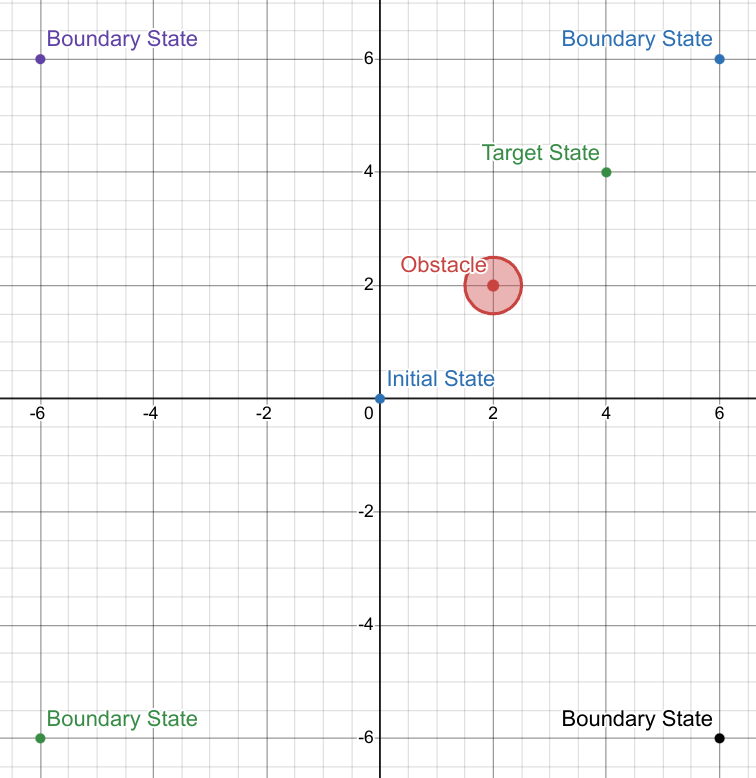

The image might give you a rough idea on what we are expecting.

# Use Monte Carlo Estimate:
Using Monte carlo estimate as,
\begin{align*}
    L(\theta)&= \frac{1}{a}\sum_{i=1}^{a} \max(0,-\rho_{\theta}(x_i)) + \frac{1}{b}\sum_{i=1}^{b} \max(0, \rho_{\theta}(y_i)) + \frac{1}{c}\sum_{i=1}^{c} \max(0,\gamma -\nabla . [(\rho_{\theta}f+ g \Psi_{\theta})(z_i)]) - \gamma\\
    &=\frac{1}{a}\sum_{i=1}^{a}\max(0,-\rho_{\theta}(0,0 ,\theta_i)) + \frac{1}{b}\sum_{i=1}^{b} \max(0, \rho_{\theta}(y_i)) + \frac{1}{c}\sum_{i=1}^{c} \max(0, \gamma-\nabla . [(\rho_{\theta}f+ g \Psi_{\theta})(z_i)]) -\gamma \\
\end{align*}


and the SMT constraint should be:
\begin{align*}
    \Phi_{\epsilon}(x):= ( \rho_{x \in X_u}(x) \geq 0) \wedge (\rho_{x \in X_o}(x) < 0) \wedge ( \nabla . [ (\rho f+ g \Psi)_{x\in X}(x)] < 0)
\end{align*}

# Precompute the divergence:
To avoid numerical errors while evaluating the divergence,
\begin{align*}
    \nabla. f &= \frac{\partial v \cos( \theta)}{\partial x}+ \frac{\partial v \sin( \theta)}{\partial y} +  \frac{\partial 0}{\partial \theta}\\
    &= 0 \\
    \nabla. g &= \frac{\partial 0}{\partial x}+ \frac{0}{\partial y} +  \frac{\partial 1}{\partial \theta}\\
    &= 0 \\
\end{align*}

In [41]:
import torch

torch.cuda.empty_cache()  # Clear the GPU memory cache


In [42]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt

import random

In [43]:
torch.manual_seed(42)

random.seed()



In [44]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# synthetic training and testing data

In [45]:
# xo = {(x,y,theta)|(x,y,theta) in R^3, |(x,y)-(2,2)| <= 0.5^2 for any theta}
# Parameters
num_samples_X = 1000  # Number of samples for state space X
num_samples_X_u = 100  # Number of samples for unsafe set X_u
theta_range = (-np.pi, np.pi)  # Range for theta

# Generate state space X
def generate_X(num_samples):
    x = torch.FloatTensor(num_samples).uniform_(-6, 6)  # x in [-6, 6]
    y = torch.FloatTensor(num_samples).uniform_(-6, 6)  # y in [-6, 6]
    theta = torch.FloatTensor(num_samples).uniform_(*theta_range)  # theta in [-pi, pi]
    return torch.stack([x, y, theta], dim=1)


# Generate initial set X_o
def generate_X_o():
    theta = torch.FloatTensor(1).uniform_(*theta_range)  # Random theta
    return torch.tensor([[0.0, 0.0, theta.item()]], dtype=torch.float32)  # Single point at (0, 0, theta)


# Generate unsafe set X_u
def generate_X_u(num_samples):
    samples = []
    while len(samples) < num_samples:
        # Randomly sample points near the center of the ball
        x = torch.FloatTensor(1).uniform_(1.5, 2.5)  # x near 2
        y = torch.FloatTensor(1).uniform_(1.5, 2.5)  # y near 2
        theta = torch.FloatTensor(1).uniform_(*theta_range)  # Random theta
        
        # Check if the point is inside the ball of radius 0.5
        if (x - 2).pow(2) + (y - 2).pow(2) <= 0.5**2:
            samples.append([x.item(), y.item(), theta.item()])
    
    return torch.tensor(samples, dtype=torch.float32)

# Generate the data
X = generate_X(num_samples_X)  # State space
X_o = generate_X_o()           # Initial set
X_u = generate_X_u(num_samples_X_u)  # Unsafe set

# Print details
print(f"State space X: {X.shape}")
print(f"Initial set X_o: {X_o.shape}, values: {X_o}")
print(f"Unsafe set X_u: {X_u.shape}")

State space X: torch.Size([1000, 3])
Initial set X_o: torch.Size([1, 3]), values: tensor([[0.0000, 0.0000, 2.4186]])
Unsafe set X_u: torch.Size([100, 3])


# Define the dynamics here:

In [46]:
import math

def f_value(f_val, g_val, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val * u

def f(x): 
    v=1
    val = torch.tensor([v* torch.cos(x[2]),v * torch.sin(x[2]),0], device=device)
    return val


def g(x):
    return torch.tensor([0, 0 ,1], dtype=torch.float32, device=device)



# Your Network here:

In [47]:
import torch.nn as nn

class DensityFunctionNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DensityFunctionNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        
        # Initialize weights to zero and bias to zero (or any desired value)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)

        # Freeze weights to ensure they cannot be updated
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        # Directly return the bias as output
        return self.linear_layer.bias




# Evaluate loss

In [48]:
def gradient_at_given_function(func,x):
    """ The function returns the gradient of given function at x"""
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
   # Compute the output of the function
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Extract scalar from output tensor
    output = output.squeeze()  # Remove batch and channel dimensions (shape: ())
    
    # Ensure the function returns a scalar
    if output.dim() != 0:
        raise ValueError(f"The function must return a scalar value, but got shape {output.shape}.")
    
    # Compute the gradient
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    
    return grad


def control_density_risk2(x, rho_in, u_rho_in, fu, gu):
    ret_Val = []
    for i in range(x.shape[0]):

        grad_at_rho = gradient_at_given_function(rho_in, x[i])
        grad_at_u_rho = gradient_at_given_function(u_rho_in, x[i])
       

        val = grad_at_rho @ fu(x[i]) + grad_at_u_rho@ gu(x[i])
        ret_Val.append(val)
    ret_Val = torch.stack(ret_Val)
    return ret_Val


In [49]:

def control_density_loss(xu, xo, x, rho_in, u_rho_in, fu, gu,gamma):

    # rho loss for xu
    rho1 = rho_in(xu)
    rho_loss1 = F.relu(-rho1).mean()

    # rho loss for xo
    rho2 = rho_in(xo)
    rho_loss2 = F.relu(rho2).mean()


    # divergence loss for x
    divergence1 = control_density_risk2(x,rho_in, u_rho_in, fu, gu)
    divergence2 = control_density_risk2(xu,rho_in, u_rho_in, fu, gu)
    divergence3 = control_density_risk2(xo,rho_in, u_rho_in, fu, gu)

    loss1 = F.relu(gamma(x)-divergence1).mean()
    loss2 = F.relu(gamma(xu)-divergence2).mean()
    loss3 = F.relu(gamma(xo)-divergence3).mean()


    gamma_loss = F.relu(-gamma(x)).mean()
    return loss1+ loss2 + loss3 + rho_loss1 + rho_loss2 + gamma_loss




In [50]:

rho_nn = DensityFunctionNet(input_dim=3, hidden_dim=6, output_dim=1).to(device)
u_rho_nn = DensityFunctionNet(input_dim=3, hidden_dim=6, output_dim=1).to(device)
gamma_nn = GammaFunctionNet(input_dim=3, output_dim=1).to(device)

loss = control_density_loss(X_o,X_u,X, rho_nn, u_rho_nn, f, g, gamma_nn)
print(loss)


tensor(2.6726, grad_fn=<AddBackward0>)


# Learn symbolic representation of your network

In [ ]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

def candidate_constraint_learnt(vars, rho_in, u_rho_in_1, u_rho_in_2):
    """Compute the candidate constraint"""
    rho = SymbolicNN(rho_in)
    u_rho_1 = SymbolicNN(u_rho_in_1)
    u_rho_2 = SymbolicNN(u_rho_in_2)
    
    # Get Symbolic Forward Pass
    rho_out = rho.forward_symbolic(vars)
    u_rho_out_1 = u_rho_1.forward_symbolic(vars)
    u_rho_out_2 = u_rho_2.forward_symbolic(vars)
    
    g = 0.28
    m = 11.2
    I = 0.0462
    r = 0.156
    d = 0.1

    # Compute vector field as symbolic expressions
    f_val = [
        vars[3],vars[4],vars[5], -d *vars[0]/m , (-d * vars[1]- m *g) /m,0
    ]  # f(x)
    g_val_1 = [0,0,0,cos(vars[2])/m,sin(vars[2])/m, r/I]  # g(x)
    g_val_2 = [0,0,0,-sin(vars[2])/m,-cos(vars[2])/m,0]  # g(x)

    # Compute f*rho + g*u_rho (element-wise multiplication)
    vector_field = [
        f_val[i] * rho_out[0] + g_val_1[i] * u_rho_out_1[0] + g_val_2[i] * u_rho_out_2[0]
        for i in range(len(vars)) 
    ]

    # Compute divergence as the sum of partial derivatives
    divergence = sum(
        vector_field[i].Differentiate(vars[i])
        for i in range(len(vars))
    )

    return divergence, rho_out[0]



# Training

In [ ]:
# prepare the config and stuff for smt solver
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
x1 = Variable("x1")
x2 = Variable("x2")


In [ ]:

def train_density(xu,xo,x,epochs=2000, learning_rate=1e-1):
    loss_total_density = []
    valid = False

    rho_nn = DensityFunctionNet(input_dim=6, hidden_dim=6, output_dim=1).to(device)
    u_rho_nn = DensityFunctionNet(input_dim=6, hidden_dim=6, output_dim=1).to(device)
    gamma_nn = GammaFunctionNet(input_dim=6, output_dim=1).to(device)

 
    optimizer = torch.optim.SGD(
        list(rho_nn.parameters()) + list(u_rho_nn.parameters()) + list(gamma_nn.parameters()),
        lr=learning_rate
    )

    # optimizer = torch.optim.Adam(
    #     list(rho_nn.parameters()) + list(u_rho_nn.parameters()) + list(gamma_nn.parameters()),
    #     lr=learning_rate
    # )

    print("Start the training")
    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()

            # compute losses
            loss = control_density_loss(xu,xo,x, rho_nn, u_rho_nn, f,g, gamma_nn)

            # BackPropagation
            loss.backward()
            optimizer.step()

            
            print(f"Epoch : {epoch}, current loss: {loss.item()}")
            loss_total_density.append(loss.item())

            if loss.item() == 0:
                break
            # check counter examples 
            if epoch % 10 == 0:
                vars = [Variable("x1"), Variable("x2")]
                divergence_learnt, rho_learnt = candidate_constraint_learnt(vars, rho_nn, u_rho_nn)
                result = Checkdivergence(vars, rho_learnt, divergence_learnt,  ball_lb, ball_ub, config,0)

                if (result):
                    print("_______________________________________________________")
                    print("Not a Density function")
                    print(result)
                    x , counter_example = AddCounterexamples(x,result,N=10,device=device)
                    risk_examine = control_density_risk2(counter_example, rho_nn, u_rho_nn, f,g)
                    rho_examine = rho_nn(counter_example)
                    print(f"observe this, {risk_examine}")
                    print(f"observe this, {rho_examine}")
                    print("_______________________________________________________")
                else:
                    valid = True
                    print("Conditions are satisfied!")
    print(f"The learned margin is {gamma_nn(x)}")
    return loss_total_density, rho_nn, u_rho_nn, gamma_nn

        


In [ ]:
def plot_results(risks, labels):
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:

loss_density, rho_nn, u_rho_nn, gamma_nn = train_density(X_o,X_u,X,epochs=2000, learning_rate=1e-1)


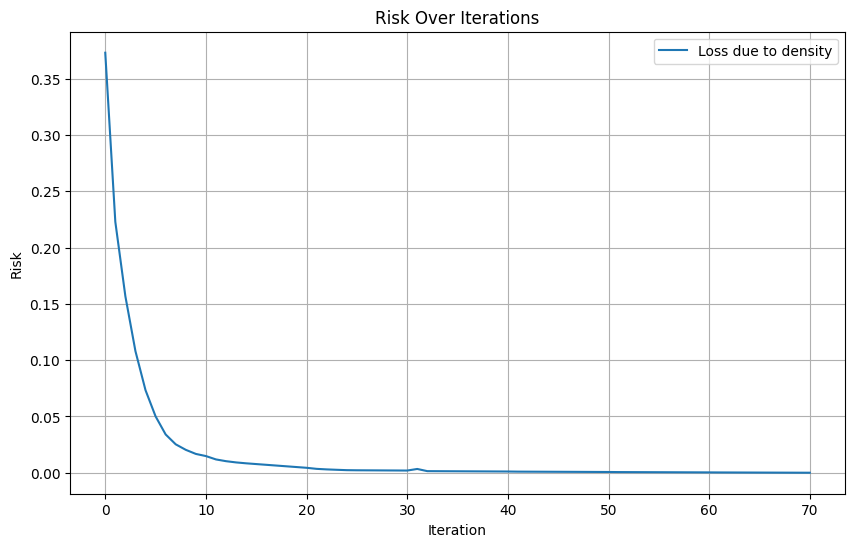

In [ ]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [ ]:
# Parameters
grid_size = 10  # Grid resolution

# Define grid for x1 and x2
x1 = torch.linspace(-1, 1, grid_size)
x2 = torch.linspace(-1, 1, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)

# Generate random values for x3, x4, x5, and x6 in [-1, 1]
x3 = torch.rand(1) * 2 - 1  # Single random value in [-1, 1]
x4 = torch.rand(1) * 2 - 1
x5 = torch.rand(1) * 2 - 1
x6 = torch.rand(1) * 2 - 1

# Repeat x3, x4, x5, x6 to match the size of x1_grid and x2_grid
x3_grid = x3.expand_as(x1_grid)
x4_grid = x4.expand_as(x1_grid)
x5_grid = x5.expand_as(x1_grid)
x6_grid = x6.expand_as(x1_grid)

# Stack grid points into shape [num_points, 6]
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel(), x5_grid.ravel(), x6_grid.ravel()], dim=1).to(device)

# Compute divergence set for the grid points
divergence_set = control_density_risk2(grid_points, rho_nn, u_rho_nn_1, u_rho_nn_2, f, g_1, g_2)

# Rescale the values to 1 and -1 for x >= 0 and x < 0 respectively
divergence_set = torch.where(divergence_set >= 0, 1, -1)

# Reshape divergence values to match the x1-x2 grid dimensions
divergence_values_reshaped = divergence_set.detach().cpu().numpy().reshape(grid_size, grid_size)


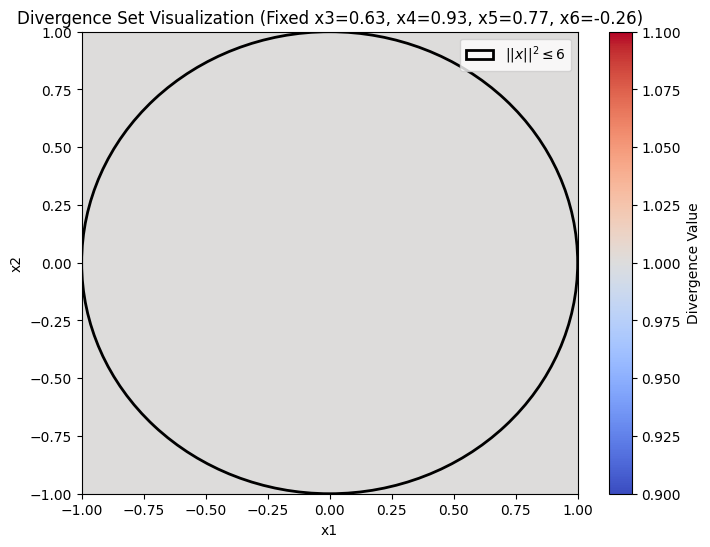

In [ ]:
import matplotlib.patches as patches

# Visualization
plt.figure(figsize=(8, 6))
plt.imshow(
    divergence_values_reshaped,
    extent=[-1, 1, -1, 1],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="Divergence Value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Divergence Set Visualization (Fixed x3={x3.item():.2f}, x4={x4.item():.2f}, x5={x5.item():.2f}, x6={x6.item():.2f})")

# Add a circle to the plot
circle = patches.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [ ]:
# Count the total number of values in the divergence set
total_values = divergence_values_reshaped.size

# Count the number of negative values
negative_values_count = (divergence_values_reshaped < 0).sum()

# Calculate the percentage of negative values
percentage_negative = negative_values_count 

print(f"The percentage of negative values in divergence_values_reshaped is {percentage_negative:.2f}")

# # PRINT the negative values taken by the divergence
# negative_values = divergence_values_reshaped[divergence_values_reshaped < 0]
# print(f"The negative values in divergence_values_reshaped are {negative_values}")

The percentage of negative values in divergence_values_reshaped is 0.00
